##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [8]:
import os

os.makedirs("data", exist_ok=True)

Checking images...

data/cat_1.jpg ✅
data/dog_1.jpg ✅
data/dog_2.jpg ✅
data/dog_3.jpg ✅


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]


DINOv2 loaded successfully ✅

Embeddings shape: (4, 384)

Predicted Clusters:
[1 0 0 0]

Best Clustering Accuracy: 1.00


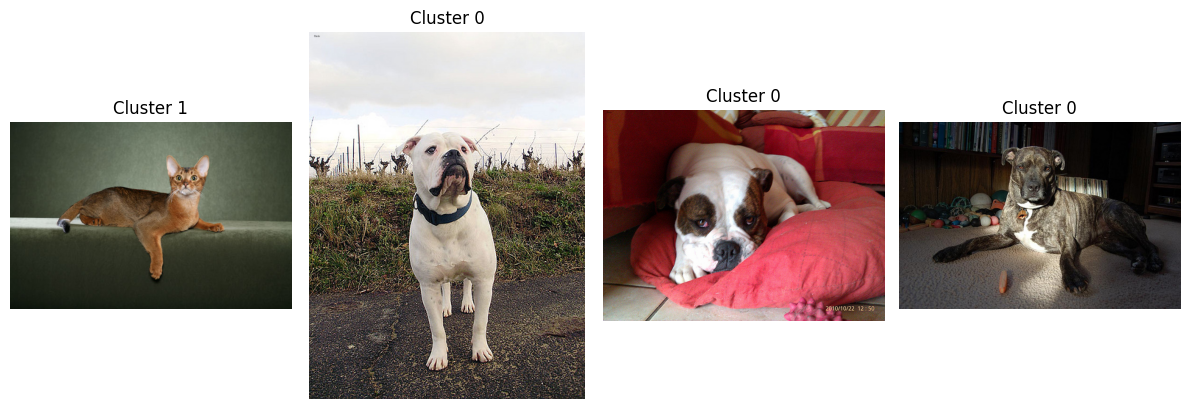

In [9]:
# Install packages
!pip install -q transformers torch torchvision scikit-learn pillow matplotlib

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from transformers import AutoImageProcessor, AutoModel

# Image paths
image_paths = [
    "data/cat_1.jpg",
    "data/dog_1.jpg",
    "data/dog_2.jpg",
    "data/dog_3.jpg"
]

# Check images exist
print("Checking images...\n")

for path in image_paths:
    if os.path.exists(path):
        print(f"{path} ✅")
    else:
        raise FileNotFoundError(f"{path} not found")

# Load DINOv2
model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

print("\nDINOv2 loaded successfully ✅")

# Extract embeddings
embeddings = []

for image_path in image_paths:

    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()

    embeddings.append(cls_embedding)

embeddings = np.array(embeddings)

print("\nEmbeddings shape:", embeddings.shape)

# Normalize features
scaler = StandardScaler()

embeddings_scaled = scaler.fit_transform(embeddings)

# KMeans clustering
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

predicted_clusters = kmeans.fit_predict(embeddings_scaled)

print("\nPredicted Clusters:")
print(predicted_clusters)

# Ground truth
# cat = 0 dog = 1
true_labels = [0, 1, 1, 1]

# Accuracy
acc1 = accuracy_score(true_labels, predicted_clusters)

acc2 = accuracy_score(true_labels, 1 - predicted_clusters)

best_accuracy = max(acc1, acc2)

print(f"\nBest Clustering Accuracy: {best_accuracy:.2f}")

# Display images
lt.figure(figsize=(12,4))

for i, image_path in enumerate(image_paths):

    image = Image.open(image_path)

    plt.subplot(1, len(image_paths), i + 1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(f"Cluster {predicted_clusters[i]}")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Image loaded successfully


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

DINOv2 model loaded

Predicted Class: pug, pug-dog

Top 5 Predictions:

pug, pug-dog              0.9290
Brabancon griffon         0.0587
feather boa, boa          0.0016
bath towel                0.0015
schipperke                0.0013


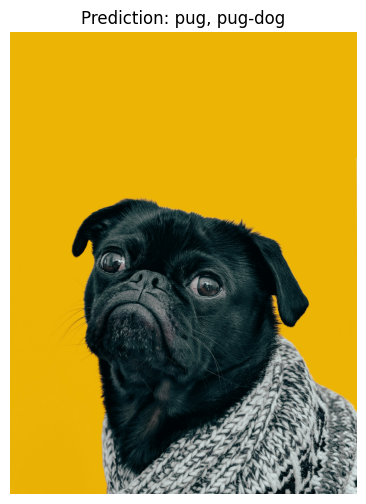

In [11]:
# Provide your solution here
# Install required packages
!pip install -q transformers torch torchvision pillow requests matplotlib

import torch
import requests
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification
)

# Image URL
image_url = "https://images.unsplash.com/photo-1517849845537-4d257902454a"

# Download image correctly
response = requests.get(image_url)

image = Image.open(BytesIO(response.content)).convert("RGB")

print("Image loaded successfully")

# Load DINOv2 classification model
model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)

model = AutoModelForImageClassification.from_pretrained(model_id)

print("DINOv2 model loaded")

# Preprocess image
inputs = processor(
    images=image,
    return_tensors="pt"
)

# Run inference
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

# Prediction
predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

print(f"\nPredicted Class: {predicted_label}")

# Top 5 predictions
probabilities = torch.nn.functional.softmax(logits, dim=-1)

top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\nTop 5 Predictions:\n")

for i in range(5):

    label = model.config.id2label[top5_catid[0][i].item()]

    prob = top5_prob[0][i].item()

    print(f"{label:<25} {prob:.4f}")

# Display image
plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(f"Prediction: {predicted_label}")

plt.axis("off")

plt.show()